In [10]:
!pip install albumentations
!pip install timm
!pip install --upgrade opencv-contrib-python

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import cv2
import random
import os

from PIL import Image
from xml.dom import minidom
import csv
import torch
from tqdm.notebook import tqdm

from sklearn.preprocessing import LabelEncoder

In [12]:
import re
pattern = r"(\d+)\.jpg$"
img_numbers=[]

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab/archive/annotated-images'):
    for filename in filenames:
        match = re.search(pattern,filename,re.IGNORECASE)
        if match:
            number = match.group(1)
            img_numbers.append(number)

img_numbers.sort()

In [13]:
def extract_xml_contents(annot_directory, image_dir, file_dir):

        file = minidom.parse(annot_directory)

        # Get the height and width for our image
        height, width = cv2.imread(image_dir).shape[:2]

        # Get the bounding box co-ordinates
        xmin = file.getElementsByTagName('xmin')
        x1 = int(xmin[0].firstChild.data)

        ymin = file.getElementsByTagName('ymin')
        y1 = int(ymin[0].firstChild.data)

        xmax = file.getElementsByTagName('xmax')
        x2 = int(xmax[0].firstChild.data)

        ymax = file.getElementsByTagName('ymax')
        y2 = int(ymax[0].firstChild.data)

        files = file.getElementsByTagName('filename')
        filename = files[0].firstChild.data
        filename = os.path.join(file_dir,filename)

        return filename, width, height, x1,y1,x2,y2

### Dataset

In [19]:
import pandas as pd

# Function to convert XML files to CSV
def xml_to_csv(data_dir):

  # List containing all our attributes regarding each image
    xml_list = []

  # Loop over each of the image and its label
    for i in img_numbers:

        mat = f"img-{i}.xml"
        image_file = f"img-{i}.jpg"

      # Full mat path
        mat_path = os.path.join(data_dir, mat)

      # Full path Image
        img_path = os.path.join(data_dir, image_file)

      # Get Attributes for each image
        value = extract_xml_contents(mat_path, img_path,data_dir)

      # Append the attributes to the mat_list
        xml_list.append(value)

  # Columns for Pandas DataFrame
    column_name = ['filename', 'width', 'height', 'xmin', 'ymin',
                 'xmax', 'ymax']

  # Create the DataFrame from mat_list
    xml_df = pd.DataFrame(xml_list, columns=column_name)

  # Return the dataframe
    return xml_df

# Run the function to convert all the xml files to a Pandas DataFrame
labels_df = xml_to_csv(data_dir="/content/drive/MyDrive/Colab/archive/annotated-images")

# Saving the Pandas DataFrame as CSV File
labels_df.to_csv(('dataset.csv'), index=None)

In [20]:
labels_df

,filename,width,height,xmin,ymin,xmax,ymax
0,/content/drive/MyDrive/Colab/archive/annotated...,720,720,213,240,525,378
1,/content/drive/MyDrive/Colab/archive/annotated...,720,720,285,214,444,355
2,/content/drive/MyDrive/Colab/archive/annotated...,720,720,235,272,434,388
3,/content/drive/MyDrive/Colab/archive/annotated...,720,720,228,303,394,432
4,/content/drive/MyDrive/Colab/archive/annotated...,720,720,230,246,492,550
...,...,...,...,...,...,...,...
660,/content/drive/MyDrive/Colab/archive/annotated...,720,720,288,233,440,366
661,/content/drive/MyDrive/Colab/archive/annotated...,720,720,257,306,382,409
662,/content/drive/MyDrive/Colab/archive/annotated...,720,720,245,263,477,348
663,/content/drive/MyDrive/Colab/archive/annotated...,720,720,505,44,585,101


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset 2

In [ ]:
# Read the CSV file and rename the columns
labels_df2 = pd.read_csv("/kaggle/input/training-setzip/train/labels.csv")
labels_df2.columns = ['filename', 'LabelName', 'xmin', 'xmax', 'ymin', 'ymax']
labels_df2.drop("LabelName", axis=1, inplace=True)

# Add a new column with the image filename and path
labels_df2['filename'] = labels_df2['filename'].apply(lambda x: "/kaggle/input/training-setzip/train/images/" + x)

# Add new columns with the image height and width
heights, widths = [], []
for _, row in labels_df2.iterrows():
    height, width = cv2.imread(row['filename']).shape[:2]
    heights.append(height)
    widths.append(width)

labels_df2 = labels_df2.assign(height=heights, width=widths)

# Print the resulting DataFrame
labels_df2

,filename,xmin,xmax,ymin,ymax,height,width
0,/kaggle/input/training-setzip/train/images/1.jpg,0,131,140,263,720,720
1,/kaggle/input/training-setzip/train/images/1.jpg,168,487,279,449,720,720
2,/kaggle/input/training-setzip/train/images/1.jpg,1,144,34,109,720,720
3,/kaggle/input/training-setzip/train/images/2.jpg,57,952,271,505,600,1200
4,/kaggle/input/training-setzip/train/images/3.jpg,225,416,292,439,720,720
...,...,...,...,...,...,...,...
1366,/kaggle/input/training-setzip/train/images/672...,0,182,274,370,484,726
1367,/kaggle/input/training-setzip/train/images/672...,0,176,166,227,484,726
1368,/kaggle/input/training-setzip/train/images/673...,121,444,114,188,387,620
1369,/kaggle/input/training-setzip/train/images/674...,50,158,82,168,183,275


In [ ]:
labels_df = pd.concat([labels_df1,labels_df2],axis=0)
labels_df

,filename,width,height,xmin,ymin,xmax,ymax
0,/kaggle/input/annotated-potholes-dataset/annot...,720,720,213,240,525,378
1,/kaggle/input/annotated-potholes-dataset/annot...,720,720,285,214,444,355
2,/kaggle/input/annotated-potholes-dataset/annot...,720,720,235,272,434,388
3,/kaggle/input/annotated-potholes-dataset/annot...,720,720,228,303,394,432
4,/kaggle/input/annotated-potholes-dataset/annot...,720,720,230,246,492,550
...,...,...,...,...,...,...,...
1366,/kaggle/input/training-setzip/train/images/672...,726,484,0,274,182,370
1367,/kaggle/input/training-setzip/train/images/672...,726,484,0,166,176,227
1368,/kaggle/input/training-setzip/train/images/673...,620,387,121,114,444,188
1369,/kaggle/input/training-setzip/train/images/674...,275,183,50,82,158,168


In [21]:
DATA_DIR = "/content/drive/MyDrive/Colab/archive/annotated-images"

In [22]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
IMG_SIZE = 128
LR = 0.01
EPOCHS = 100
MODEL_NAME = "res2net50d.in1k"
NUM_COR = 4

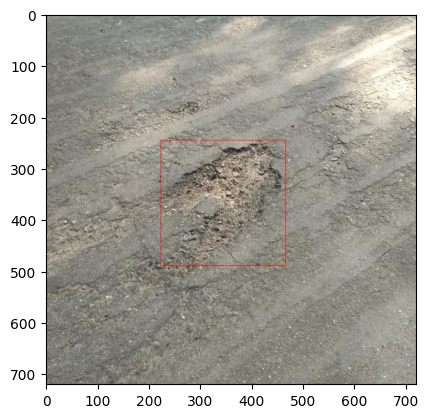

In [23]:
row = labels_df.iloc[12]

img = cv2.imread(row.filename)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

pt1 = (row.xmin, row.ymin)
pt2 = (row.xmax, row.ymax)

bnd_box_img = cv2.rectangle(img, pt1, pt2, (255,0,0),1)

plt.imshow(bnd_box_img)

In [24]:
train_df, valid_df = train_test_split(labels_df,test_size=0.10,random_state=42)

In [25]:
import albumentations as A

In [26]:
train_augs = A.Compose([
    A.Resize(IMG_SIZE,IMG_SIZE),
], bbox_params=A.BboxParams(format="pascal_voc",label_fields=["class_labels"]))

valid_augs = A.Compose([
    A.Resize(IMG_SIZE,IMG_SIZE),
], bbox_params=A.BboxParams(format="pascal_voc",label_fields=["class_labels"]))

In [27]:
class PotholeDataset(torch.utils.data.Dataset):
    def __init__(self,df,augs=None):
        self.df = df
        self.augs = augs

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        row = self.df.iloc[idx]
        xmin = row.xmin
        ymin = row.ymin
        xmax = row.xmax
        ymax = row.ymax
        bbox = [[xmin,ymin,xmax,ymax]]

        img_path = row.filename
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        if self.augs:
            data = self.augs(image = img, bboxes=bbox, class_labels = [None])
            img = data["image"]

            bbox = data["bboxes"][0]

        img = torch.from_numpy(img).permute(2,0,1) / 255.0
        bbox = torch.Tensor(bbox)

        return img, bbox

In [28]:
trainset = PotholeDataset(train_df,train_augs)
validset = PotholeDataset(valid_df,valid_augs)

In [29]:
len(validset)

67

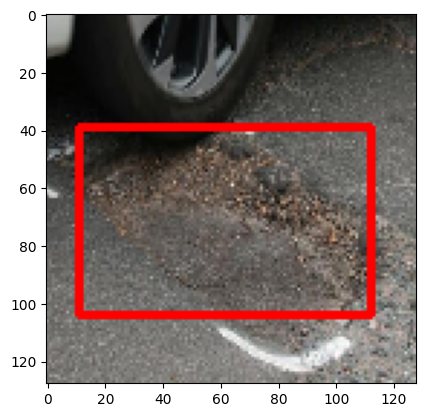

In [30]:
img, bbox = trainset[0]

xmin, ymin, xmax, ymax = bbox

pt1 = (int(xmin), int(ymin))
pt2 = (int(xmax), int(ymax))

bnd_img = cv2.rectangle(img.permute(1, 2, 0).numpy(),pt1, pt2,(255,0,0),2)
plt.imshow(bnd_img)

In [31]:
trainloader = torch.utils.data.DataLoader(trainset,batch_size=BATCH_SIZE,shuffle=True)
validLoader = torch.utils.data.DataLoader(validset,batch_size=BATCH_SIZE,shuffle=False)

In [32]:
print("Total no. batches in trainloader : {}".format(len(trainloader)))
print("Total no. batches in validloader : {}".format(len(validLoader)))

Total no. batches in trainloader : 38
Total no. batches in validloader : 5


In [33]:
for images,bboxes in trainloader:
    break


print("Shape of one batch images : {}".format(images.shape))
print("Shape of one batch bboxes : {}".format(bboxes.shape))

Shape of one batch images : torch.Size([16, 3, 128, 128])
Shape of one batch bboxes : torch.Size([16, 4])


In [34]:
from torch import nn
import torchvision
import timm

In [35]:
class PotholeModel(nn.Module):
    def __init__(self) -> None:
        super(PotholeModel,self).__init__()

        self.backbone = timm.create_model(MODEL_NAME,pretrained=True,num_classes=4)


    def forward(self,images,gt_bboxes=None):
        predBboxes = self.backbone(images)

        if gt_bboxes != None:
            loss1 = torchvision.ops.complete_box_iou_loss(predBboxes,gt_bboxes,reduction="sum")
            loss2 = nn.functional.smooth_l1_loss(predBboxes,gt_bboxes)
            return predBboxes,loss2 + loss1

        return predBboxes

In [36]:
model = PotholeModel()
model.to(DEVICE)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/103M [00:00<?, ?B/s]

PotholeModel(
  (backbone): ResNet(
    (conv1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottle2neck(
        (conv1): Conv2d(64, 104, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(104, eps=1e-05, momentum=0.1, affine=True, track_running

In [37]:
random_img = torch.rand(1,3,140,140).to(DEVICE)
model(random_img).shape

torch.Size([1, 4])

In [38]:
def train(model,dataLoader,optimizer):
    total_loss = 0
    model.train()

    for data in tqdm(dataLoader):
        images,gt_bboxes = data
        images,gt_bboxes = images.to(DEVICE), gt_bboxes.to(DEVICE)

        bboxes, loss = model(images,gt_bboxes)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataLoader)

In [39]:
def eval(model,dataLoader):
    total_loss = 0
    model.eval()

    with torch.inference_mode():
        for data in tqdm(dataLoader):
            images,gt_bboxes = data
            images,gt_bboxes = images.to(DEVICE), gt_bboxes.to(DEVICE)

            bboxes, loss = model(images,gt_bboxes)

            total_loss += loss.item()

        return total_loss / len(dataLoader)

In [40]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [42]:
best_valid_loss = np.inf

for i in range(EPOCHS):
    train_loss = train(model,trainloader,optimizer)
    valid_loss = eval(model,validLoader)

    if valid_loss < best_valid_loss:
        torch.save(model.state_dict(),"best_model.pt")
        print("WEIGHTS SAVEDD!!")
        best_valid_loss = valid_loss

    print(f"Epoch : {i + 1}, train Loss : {train_loss:.4f}, valid loss : {valid_loss:.4f}")

  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

WEIGHTS SAVEDD!!
Epoch : 1, train Loss : 63.4371, valid loss : 259612.8250


  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

WEIGHTS SAVEDD!!
Epoch : 2, train Loss : 30.9876, valid loss : 41.7031


  0%|          | 0/38 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [43]:
def compare_plots(image, gt_bbox, out_bbox):

    xmin, ymin, xmax, ymax = gt_bbox

    pt1 = (int(xmin), int(ymin))
    pt2 = (int(xmax), int(ymax))

    out_xmin, out_ymin, out_xmax, out_ymax = out_bbox[0]

    out_pt1 = (int(out_xmin), int(out_ymin))
    out_pt2 = (int(out_xmax), int(out_ymax))

    out_img = cv2.rectangle(image.squeeze().permute(1, 2, 0).cpu().numpy(),pt1, pt2,(0,255,0),2)
    out_img = cv2.rectangle(out_img,out_pt1, out_pt2,(255,0,0),2)
    plt.imshow(out_img)

tensor([[31.0674, 48.9413, 93.7527, 94.1960]])
tensor([34.0948, 64.8533, 84.0813, 98.9867])


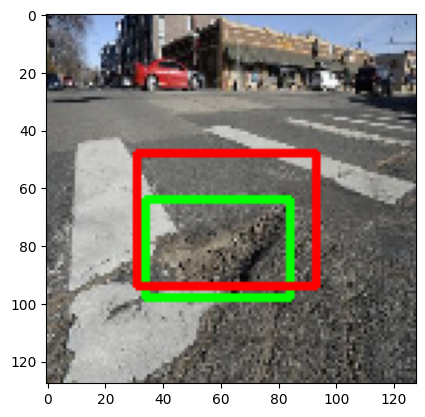

In [44]:
model.load_state_dict(torch.load("best_model.pt"))

model.eval()
with torch.inference_mode():
    image, gt_bbox = validset[5]
    image = image.unsqueeze(0).to(DEVICE)

    out_bbox = model(image)
    compare_plots(image,gt_bbox,out_bbox)

    print(out_bbox)
    print(gt_bbox)

tensor([[31.3692, 48.8458, 90.9564, 91.3502]])
tensor([11.6616, 27.3067, 40.5380, 40.9600])


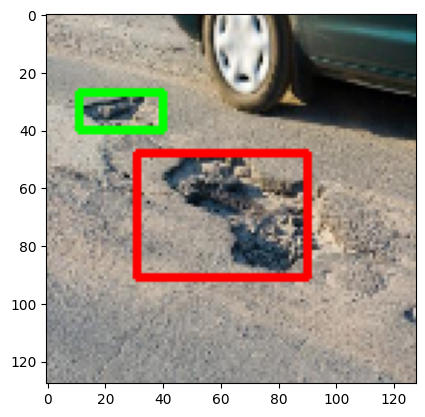

In [45]:
model.load_state_dict(torch.load("best_model.pt"))

model.eval()
with torch.inference_mode():
    image, gt_bbox = validset[12]
    image = image.unsqueeze(0).to(DEVICE)

    out_bbox = model(image)
    compare_plots(image,gt_bbox,out_bbox)

    print(out_bbox)
    print(gt_bbox)

tensor([[30.7556, 47.3382, 85.3639, 85.5778]])
tensor([ 39.6444,  68.8000,  67.9111, 102.5778])


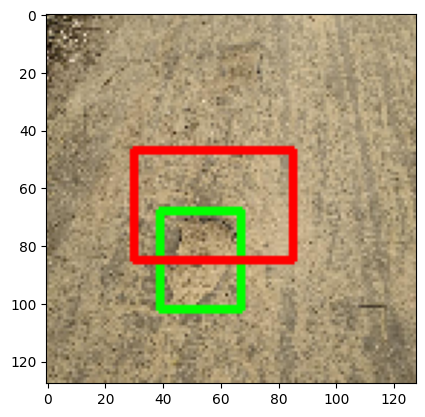

In [46]:
model.load_state_dict(torch.load("best_model.pt"))

model.eval()
with torch.inference_mode():
    image, gt_bbox = validset[13]
    image = image.unsqueeze(0).to(DEVICE)

    out_bbox = model(image)
    compare_plots(image,gt_bbox,out_bbox)

    print(out_bbox)
    print(gt_bbox)

tensor([[30.8499, 46.7666, 80.6560, 80.7035]])
tensor([36.2667, 45.3333, 80.3556, 75.5556])


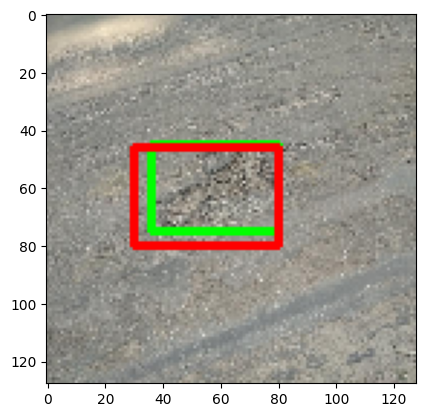

In [47]:
model.load_state_dict(torch.load("best_model.pt"))

model.eval()
with torch.inference_mode():
    image, gt_bbox = validset[15]
    image = image.unsqueeze(0).to(DEVICE)

    out_bbox = model(image)
    compare_plots(image,gt_bbox,out_bbox)

    print(out_bbox)
    print(gt_bbox)

tensor([[30.9302, 48.3538, 90.9295, 91.3032]])
tensor([ 3.8424, 54.6133, 40.8255, 65.7067])


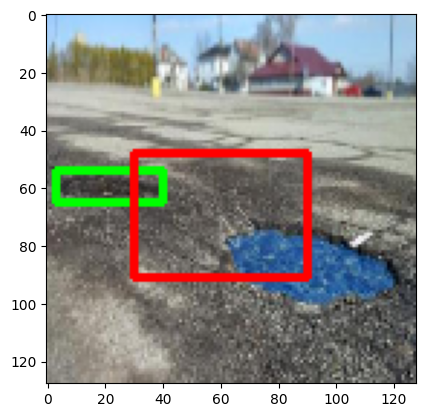

In [48]:
model.load_state_dict(torch.load("best_model.pt"))

model.eval()
with torch.inference_mode():
    image, gt_bbox = validset[23]
    image = image.unsqueeze(0).to(DEVICE)

    out_bbox = model(image)
    compare_plots(image,gt_bbox,out_bbox)

    print(out_bbox)
    print(gt_bbox)

tensor([[31.1378, 49.2061, 94.9449, 95.4152]])
tensor([ 69.0526,  49.0667, 123.7895,  67.8400])


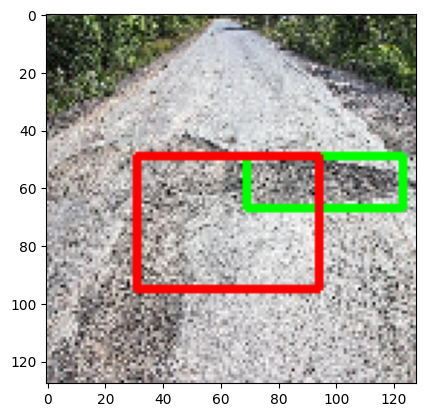

In [49]:
model.load_state_dict(torch.load("best_model.pt"))

model.eval()
with torch.inference_mode():
    image, gt_bbox = validset[3]
    image = image.unsqueeze(0).to(DEVICE)

    out_bbox = model(image)
    compare_plots(image,gt_bbox,out_bbox)

    print(out_bbox)
    print(gt_bbox)